# Data Exploratory 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from scipy import stats
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("dataset_mood_smartphone.csv", sep=",").drop(columns=["Unnamed: 0"])
df.head()

In [ ]:
VALID_RANGES = {
    "mood":                  (1, 10),
    "circumplex.arousal":    (-2, 2),
    "circumplex.valence":    (-2, 2),
    "activity":              (0, 1),
    "screen":                (0, None),      # non-negative
    "call":                  (0, None),
    "sms":                   (0, None),
}


In [ ]:
print("=" * 60)
print("1. BASIC SHAPE")
print("=" * 60)
print(f"Total rows       : {len(df):,}")
print(f"Columns          : {df.columns.tolist()}")
print(f"Unique users     : {df['id'].nunique()}")
print(f"Unique variables : {df['variable'].nunique()}")
print(f"Variables        : {sorted(df['variable'].unique())}")
print(f"Date range       : {df['time'].min()}  →  {df['time'].max()}")
# print(f"Span (days)      : {(df['time'].max() - df['time'].min()).days}")

In [ ]:
print("=" * 60)
print("2. PER-VARIABLE STATISTICS")
print("=" * 60)
 
stats_rows = []
for var, grp in df.groupby("variable"):
    vals = grp["value"].dropna()
    lo, hi = VALID_RANGES.get(var, (0, None))
    out_of_range = (vals < lo).sum() if lo is not None else 0
    if hi is not None:
        out_of_range += (vals > hi).sum()
    stats_rows.append({
        "variable":      var,
        "count":         len(vals),
        "missing":       grp["value"].isna().sum(),
        "mean":          round(vals.mean(), 3),
        "std":           round(vals.std(), 3),
        "min":           round(vals.min(), 3),
        "max":           round(vals.max(), 3),
        "skewness":      round(vals.skew(), 3),
        "out_of_range":  out_of_range,
    })
 
stats_df = pd.DataFrame(stats_rows).set_index("variable")
print(stats_df.to_string())
print()


In [ ]:
list(df['variable'].unique())

## Task 1B: Data Cleaning

In [ ]:
df["date"] = pd.to_datetime(df["time"]).dt.date
df.head()

In [ ]:
def remove_invalid_values(df):
    df = df.copy()
    initial_rows = len(df)

    removal_stats = {}

    # Initialize all variables in stats
    for var in df["variable"].unique():
        removal_stats[var] = 0

    keep_mask = pd.Series(True, index=df.index)

    # ---- RULE-BASED VALIDATION ----
    rules = {
        "mood": (df["value"] >= 1) & (df["value"] <= 10),
        "circumplex.arousal": (df["value"] >= -2) & (df["value"] <= 2),
        "circumplex.valence": (df["value"] >= -2) & (df["value"] <= 2),
        "activity": (df["value"] >= 0) & (df["value"] <= 1),
        "call": df["value"].isin([0, 1]),
        "sms": df["value"].isin([0, 1]),
    }

    for var, rule in rules.items():
        mask = (df["variable"] == var)
        invalid = mask & ~rule
        removal_stats[var] += invalid.sum()
        keep_mask &= ~invalid

    # ---- DURATION VARIABLES ----
    usage_mask = df["variable"].str.startswith("appCat.") | (df["variable"] == "screen")
    invalid_usage = usage_mask & ((df["value"] < 0) | (df["value"] > 86400))

    for var in df.loc[usage_mask, "variable"].unique():
        var_invalid = (df["variable"] == var) & ((df["value"] < 0) | (df["value"] > 86400))
        removal_stats[var] += var_invalid.sum()

    keep_mask &= ~invalid_usage

    # ---- FINAL FILTER ----
    removed_df = df.loc[~keep_mask].copy()
    df_clean = df.loc[keep_mask].copy()

    print(f"Rows before: {initial_rows}, after: {len(df_clean)}")
    
    return df_clean, removed_df, removal_stats


clean_df, removed_df, removal_stats = remove_invalid_values(df)
print("\nRemoved values per variable:")
for var in sorted(removal_stats.keys()):
    print(f"{var:25s}: {removal_stats[var]}")

In [ ]:
# def iqr_winsorize(df):
#     df = df.copy()
#     stats = []

#     if "variable" not in df.columns:
#         raise KeyError("The input dataframe must contain a 'variable' column.")

#     processed_groups = []
#     for var, group in df.groupby("variable", sort=False):
#         group = group.copy()

#         Q1 = group["value"].quantile(0.25)
#         Q3 = group["value"].quantile(0.75)
#         IQR = Q3 - Q1

#         lower = Q1 - 1.5 * IQR
#         upper = Q3 + 1.5 * IQR

#         # Domain constraint for duration variables
#         if var.startswith("appCat") or var == "screen":
#             lower = max(lower, 0)

#         before = group["value"]
#         after = before.clip(lower, upper)

#         num_outliers = ((before < lower) | (before > upper)).sum()
#         num_clipped = (before != after).sum()

#         stats.append({
#             "variable": var,
#             "lower": lower,
#             "upper": upper,
#             "outliers_detected": int(num_outliers),
#             "values_clipped": int(num_clipped)
#         })

#         group["value"] = after
#         processed_groups.append(group)

#     df = pd.concat(processed_groups, axis=0).sort_index()
#     stats_df = pd.DataFrame(stats)
#     return df, stats_df


# clean_df, iqr_stats = iqr_winsorize(clean_df)

# print("\nIQR Stats:")
# display(iqr_stats)

In [ ]:
def aggregate_daily(df):
    df = df.copy()

    # Convert time → datetime
    df["time"] = pd.to_datetime(df["time"])

    # Extract date
    df["date"] = df["time"].dt.date

    mean_vars = ["mood", "activity", "circumplex.arousal", "circumplex.valence"]

    df_mean = df[df["variable"].isin(mean_vars)].pivot_table(
        index=["id", "date"],
        columns="variable",
        values="value",
        aggfunc="mean"
    )

    df_sum = df[~df["variable"].isin(mean_vars)].pivot_table(
        index=["id", "date"],
        columns="variable",
        values="value",
        aggfunc="sum"
    )

    df_daily = pd.concat([df_mean, df_sum], axis=1).reset_index()

    return df_daily

df_daily = aggregate_daily(clean_df)

duration_vars = [col for col in df_daily.columns if "appCat" in col or col in ["screen", "call", "sms"]]

df_daily[duration_vars] = df_daily[duration_vars].fillna(0)

print(f"Daily aggregated shape: {df_daily.shape}")
df_daily.head()

In [ ]:
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.sort_values(['id', 'date']).set_index(['id', 'date'])
display(df_daily.head())
display(df_daily.tail())

In [ ]:
def make_complete_panel(df):
    full = []

    for user_id, group in df.groupby(level=0):
        idx = pd.date_range(
            start=group.index.get_level_values(1).min(),
            end=group.index.get_level_values(1).max(),
            freq='D'
        )
        group = group.droplevel(0)
        group = group.reindex(idx)
        group['id'] = user_id
        group.index.name = 'date'
        group = group.reset_index().set_index(['id', 'date'])
        full.append(group)

    return pd.concat(full)

df_panel = make_complete_panel(df_daily).sort_index()
print(f"Complete panel shape: {df_panel.shape}")
display(df_panel.head())

In [ ]:
missing_flags = df_panel.isna().astype(int)
missing_flags.columns = [c + "_was_missing" for c in df_panel.columns]

df_panel = pd.concat([df_panel, missing_flags], axis=1)
display(df_panel.head())

In [ ]:
missing_matrix = df_panel["mood"].isna().unstack(level=0).T.astype(float)
missing_array = np.ma.masked_invalid(missing_matrix.values)

plt.figure(figsize=(12, 6))
plt.imshow(missing_array, aspect="auto", interpolation="none", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Missing (1=missing, 0=present)")
plt.title("Missing Data Timeline")
plt.xlabel("Time (days)")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


In [ ]:
df_panel = df_panel.sort_index()

plt.figure(figsize=(12, 5))

for user in df_panel.index.get_level_values(0).unique()[:5]:  # limit to 5 users for clarity
    user_df = df_panel.loc[user]
    plt.plot(user_df.index, user_df["mood"], alpha=0.7, label=user)

plt.title("Mood Timeline Across Users")
plt.xlabel("Date")
plt.ylabel("Mood")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
key_cols = ["mood", "activity", "circumplex.arousal", "circumplex.valence"]  # adjust based on your dataset

df_panel["is_missing_day"] = df_panel[key_cols].isna().all(axis=1)

In [ ]:
def compute_gap_lengths(group):
    missing = group["is_missing_day"].values

    gaps = []
    count = 0

    for m in missing:
        if m:
            count += 1
        else:
            if count > 0:
                gaps.append(count)
            count = 0

    if count > 0:
        gaps.append(count)

    return gaps

gap_lengths = df_panel.groupby(level=0).apply(compute_gap_lengths)
all_gaps = [gap for sublist in gap_lengths for gap in sublist]
plt.figure(figsize=(10, 5))
sns.histplot(all_gaps, bins=range(1, max(all_gaps) + 1), kde=False)
plt.title("Distribution of Consecutive Missing Day Gaps")
plt.xlabel("Gap Length (days)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
threshold = 3

big_gaps = [g for g in all_gaps if g > threshold]

print("Total gaps:", len(all_gaps))
print("Big gaps (>3 days):", len(big_gaps))
print("Max gap length:", max(all_gaps))

In [ ]:
df_interp = df_panel.groupby(level=0, group_keys=False).apply(
    lambda x: x.interpolate(limit=3, limit_direction='both')
)

df_final = df_interp.groupby(level=0).transform(lambda x: x.fillna(x.mean()))

print("Final dataset shape:", df_final.shape)
display(df_final.head())


In [ ]:
print("Remaining missing values:")
print(df_final.isna().sum().sort_values(ascending=False).head(20))

In [ ]:
print("Unique users:", df_final.index.get_level_values(0).nunique())
print("Date range:", df_final.index.get_level_values(1).min(), "→", df_final.index.get_level_values(1).max())

In [ ]:
before_na = df_panel.isna().sum().sum()
after_na = df_final.isna().sum().sum()

print("Before:", before_na)
print("After:", after_na)
print("Reduction:", before_na - after_na)

In [ ]:
df_final = df_final.sort_index()

mask = (
    ~df_final.columns.str.endswith("_was_missing")
    & (df_final.columns != "is_missing_day")
)

final_cols = df_final.columns[mask]

print("Final columns for modeling:", final_cols.tolist())

df_final = df_final[final_cols].copy()

display(df_final.head())

## Task 1C: Feature Engineering

In [ ]:
df_tem = df_final.copy()
df_tem['mood_next_day'] = df_tem.groupby(level=0)['mood'].shift(-1)
df_tem = df_tem.dropna(subset=['mood_next_day'])


features = [
    'activity', 'circumplex.arousal', 'circumplex.valence', 'mood',
    'appCat.builtin', 'appCat.communication', 'appCat.entertainment',
    'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other',
    'appCat.social', 'appCat.travel', 'appCat.unknown',
    'appCat.utilities', 'appCat.weather', 'call', 'screen', 'sms',
]


In [ ]:
df_tem['mood_next_day'].hist()

In [ ]:
def mood_to_class(m):
    # if m <= 6:
    #     return 0  # low
    # elif m <= 7.5:
    #     return 1  # medium
    # else:
    #     return 2  # high
    if m <= 4:
        return 0  # low
    elif m <= 7:
        return 1  # medium
    else:
        return 2  # high

df_tem['target'] = df_tem['mood_next_day'].apply(mood_to_class)

In [ ]:
from sklearn.preprocessing import StandardScaler

df_tem[features] = df_tem.groupby(level=0, group_keys=False)[features].apply(
    lambda x: pd.DataFrame(
        StandardScaler().fit_transform(x),
        index=x.index,
        columns=x.columns
    )
)

In [ ]:
def create_sequences(df, features, target, window=5):
    X, y = [], []

    for user_id in df.index.get_level_values(0).unique():
        user_df = df.loc[user_id].sort_index()
    
        values = user_df[features].values
        targets = user_df[target].values

        for i in range(len(user_df) - window):
            X.append(values[i:i+window])
            y.append(targets[i+window])

    return np.array(X), np.array(y)

X, y = create_sequences(df_tem, features, 'target', window=5)

print(X.shape)  # (samples, 5, features)

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
import torch
import torch.nn as nn

class MoodLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        out = self.dropout(hidden[-1])
        return self.fc(out)

Epoch 2, Train Loss: 1.1015, Val Loss: 1.0817
Epoch 4, Train Loss: 1.0927, Val Loss: 1.0808
Epoch 6, Train Loss: 1.0867, Val Loss: 1.0799
Epoch 8, Train Loss: 1.0792, Val Loss: 1.0794
Epoch 10, Train Loss: 1.0811, Val Loss: 1.0791
Epoch 12, Train Loss: 1.0722, Val Loss: 1.0789
Epoch 14, Train Loss: 1.0610, Val Loss: 1.0781
Epoch 16, Train Loss: 1.0572, Val Loss: 1.0769
Epoch 18, Train Loss: 1.0491, Val Loss: 1.0753
Epoch 20, Train Loss: 1.0394, Val Loss: 1.0732
Epoch 22, Train Loss: 1.0320, Val Loss: 1.0702
Epoch 24, Train Loss: 1.0287, Val Loss: 1.0662
Epoch 26, Train Loss: 1.0159, Val Loss: 1.0612
Epoch 28, Train Loss: 0.9986, Val Loss: 1.0548
Epoch 30, Train Loss: 0.9767, Val Loss: 1.0470
Epoch 32, Train Loss: 0.9680, Val Loss: 1.0378
Epoch 34, Train Loss: 0.9548, Val Loss: 1.0268
Epoch 36, Train Loss: 0.9357, Val Loss: 1.0138
Epoch 38, Train Loss: 0.9164, Val Loss: 0.9982
Epoch 40, Train Loss: 0.8919, Val Loss: 0.9799
Epoch 42, Train Loss: 0.8701, Val Loss: 0.9591
Epoch 44, Train L

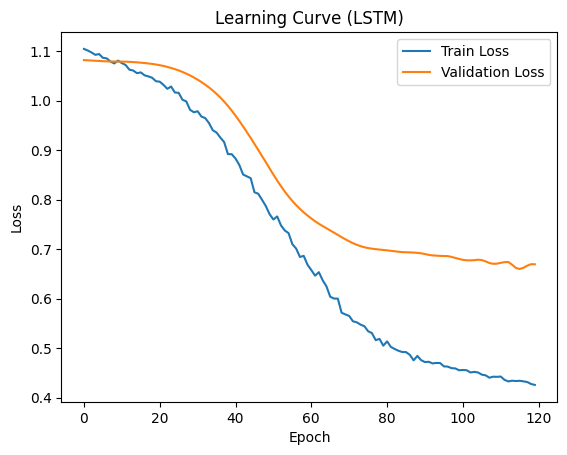

              precision    recall  f1-score   support

           1       0.60      0.64      0.62       188
           2       0.66      0.62      0.64       211

    accuracy                           0.63       399
   macro avg       0.63      0.63      0.63       399
weighted avg       0.63      0.63      0.63       399

Accuracy: 0.6265664160401002


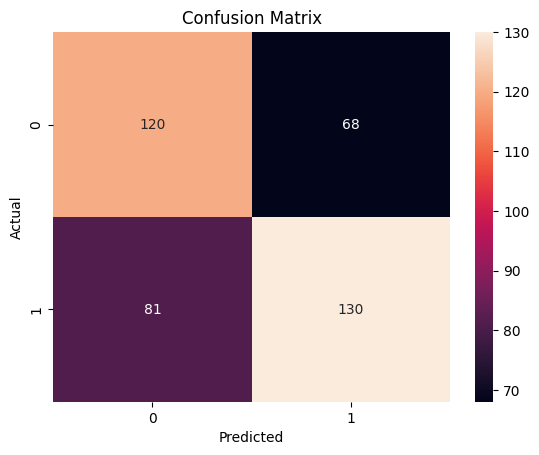

In [35]:
model_clf_lstm = MoodLSTM(input_size=X.shape[2])

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights = torch.tensor(weights, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model_clf_lstm.parameters(), lr=0.001)

train_losses = []
val_losses = []

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_test, dtype=torch.float32)
y_val_t = torch.tensor(y_test, dtype=torch.long)

for epoch in range(120):
    model_clf_lstm.train()

    outputs = model_clf_lstm(X_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model_clf_lstm.eval()
    with torch.no_grad():
        val_outputs = model_clf_lstm(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)

    val_losses.append(val_loss.item())

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve (LSTM)")
plt.legend()
plt.show()

model_clf_lstm.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    preds = model_clf_lstm(X_test_t)
    preds = torch.argmax(preds, dim=1).numpy()

print(classification_report(y_test, preds))
print("Accuracy:", (preds == y_test).mean())

cm = confusion_matrix(y_test, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [36]:
X, y = create_sequences(df_tem, features, 'mood_next_day', window=5)
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

In [37]:
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [38]:
class MoodLSTMReg(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        out = self.dropout(hidden[-1])
        return self.fc(out).squeeze()

Epoch 2, Train Loss: 47.9686, Val Loss: 51.5525
Epoch 4, Train Loss: 47.4699, Val Loss: 51.0170
Epoch 6, Train Loss: 46.9434, Val Loss: 50.4612
Epoch 8, Train Loss: 46.4087, Val Loss: 49.8732
Epoch 10, Train Loss: 45.8414, Val Loss: 49.2401
Epoch 12, Train Loss: 45.2133, Val Loss: 48.5477
Epoch 14, Train Loss: 44.5248, Val Loss: 47.7802
Epoch 16, Train Loss: 43.7751, Val Loss: 46.9191
Epoch 18, Train Loss: 42.8845, Val Loss: 45.9433
Epoch 20, Train Loss: 41.8855, Val Loss: 44.8282
Epoch 22, Train Loss: 40.7698, Val Loss: 43.5482
Epoch 24, Train Loss: 39.4894, Val Loss: 42.0783
Epoch 26, Train Loss: 38.0868, Val Loss: 40.3984
Epoch 28, Train Loss: 36.3163, Val Loss: 38.4984
Epoch 30, Train Loss: 34.4842, Val Loss: 36.3820
Epoch 32, Train Loss: 32.3769, Val Loss: 34.0661
Epoch 34, Train Loss: 30.0913, Val Loss: 31.5742
Epoch 36, Train Loss: 27.5861, Val Loss: 28.9299
Epoch 38, Train Loss: 25.0241, Val Loss: 26.1531
Epoch 40, Train Loss: 22.1834, Val Loss: 23.2614
Epoch 42, Train Loss: 19

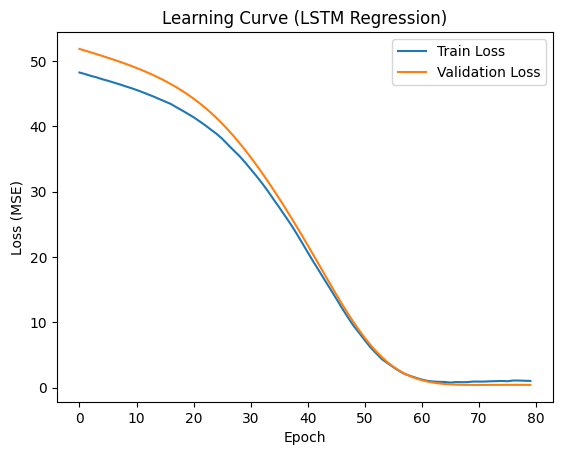

MSE: 0.10776349715549115
MAE: 0.25922124351608705


In [42]:
# Initialize model
model_reg_lstm = MoodLSTMReg(input_size=X.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_reg_lstm.parameters(), lr=0.001)

train_losses = []
val_losses = []

# Convert to tensors (FLOAT!)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_test, dtype=torch.float32)
y_val_t = torch.tensor(y_test, dtype=torch.float32)

# Training loop
for epoch in range(80):
    model_reg_lstm.train()

    outputs = model_reg_lstm(X_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model_reg_lstm.eval()
    with torch.no_grad():
        val_outputs = model_reg_lstm(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)

    val_losses.append(val_loss.item())

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")


plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Learning Curve (LSTM Regression)")
plt.legend()
plt.show()

model_reg_lstm.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    preds = model_reg_lstm(X_test_t).numpy()

preds = y_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
y_test_real = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test_real, preds)
mae = mean_absolute_error(y_test_real, preds)

print("MSE:", mse)
print("MAE:", mae)